# L05A：一次参数更新发生了什么？

只做一个batch，不启动完整训练。真实演示模型来自 classifier-ce；一次更新使用复制的模型，不改变演示包。

In [1]:
from pathlib import Path
import sys
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src/hsi_learning').is_dir() and (p / 'dataset').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from inside the HSI-Learning repository')
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np
import torch
# Notebook kernels must explicitly use inline rendering even when the CLI
# parent uses MPLBACKEND=Agg for non-interactive training scripts.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
import matplotlib.pyplot as plt
from hsi_learning.data import load_hsi_dataset
from hsi_learning.teaching_runs import load_bundle, encode_ids
from hsi_learning.teaching import patches_at, prototype_logits, prototypes, grad_cam
from hsi_learning.teaching_plots import style, maps
style()
torch.set_num_threads(2)
print('Python:', sys.executable)
print('Repository:', ROOT)


Python: D:\JupyterWorkSpace\HSI-Learning\.venv\Scripts\python.exe
Repository: D:\JupyterWorkSpace\HSI-Learning


In [2]:
from copy import deepcopy
model,cube,gt,names,split,cfg=load_bundle(ROOT/'results/teaching_ready/classifier-ce')
ids=split['train_ids'][:8]; x=patches_at(cube,ids,cfg['patch_size'])
y=torch.tensor([cfg['classes'].index(int(c)) for c in gt.ravel()[ids]])
print('Patch:',x.shape,'original IDs:',gt.ravel()[ids],'model targets:',y)
assert set(y.tolist())<=set(range(16))


Patch: torch.Size([8, 12, 9, 9]) original IDs: [ 3 15 15  3  3  3 15 15] model targets: tensor([ 2, 14, 14,  2,  2,  2, 14, 14])


In [3]:
import torch.nn.functional as F
model.eval()
with torch.no_grad(): logits=model(x)
print('Logits:',logits.shape,'predicted indices:',logits.argmax(1))
print('Cross entropy accepts logits:',float(F.cross_entropy(logits,y)))
assert logits.shape==(len(ids),16)
toy=torch.tensor([[2.,1.]]); label=torch.tensor([0])
print('Hand-check -log(softmax([2,1])[0]):',float(F.cross_entropy(toy,label)))


Logits: torch.Size([8, 16]) predicted indices: tensor([ 2, 14, 14,  2,  2,  2, 14, 14])
Cross entropy accepts logits: 0.03661684691905975
Hand-check -log(softmax([2,1])[0]): 0.31326165795326233


In [4]:
learner=deepcopy(model); learner.eval()  # freeze BN/Dropout for this controlled step
optimizer=torch.optim.SGD(learner.parameters(),lr=.001)
before=learner.head[-1].weight.detach().clone()
optimizer.zero_grad(); loss=F.cross_entropy(learner(x),y); loss.backward()
print('Gradient norm:',float(learner.head[-1].weight.grad.norm()))
optimizer.step()
print('Weight change:',float((learner.head[-1].weight.detach()-before).norm()))
assert not torch.equal(before,learner.head[-1].weight)
torch.testing.assert_close(before,model.head[-1].weight)
print('One batch update is not evidence of test improvement.')


Gradient norm: 0.40607818961143494
Weight change: 0.00040607861592434347
One batch update is not evidence of test improvement.


In [5]:
learner.eval()
assert learner(x).requires_grad  # eval does NOT turn off autograd
with torch.no_grad(): assert not learner(x).requires_grad
learner.train(); print('training flag:',learner.training)
print('train/eval controls BN and Dropout; grad mode controls autograd.')


training flag: True
train/eval controls BN and Dropout; grad mode controls autograd.


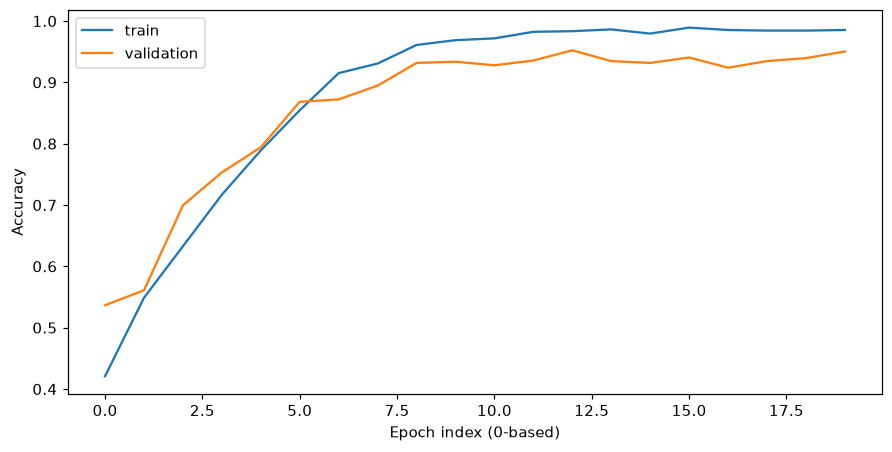

Checkpoint selected by validation: 13
Test was not used to choose the checkpoint.


In [6]:
import json
history=json.loads((ROOT/'results/teaching_ready/classifier-ce/history.json').read_text())
fig,ax=plt.subplots(figsize=(8,4),layout='constrained')
epochs=range(1,len(history['val_accuracy'])+1)  # best_epoch is 1-based
ax.plot(epochs,history['train_accuracy'],label='train'); ax.plot(epochs,history['val_accuracy'],label='validation')
ax.axvline(cfg['best_epoch'],color='gray',linestyle=':',label=f"selected epoch {cfg['best_epoch']}")
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy'); ax.legend(); plt.show()
print('Checkpoint selected by validation:',cfg['best_epoch'])
print('Test was not used to choose the checkpoint.')


## 退出题
哪些量是参数，哪些是超参数？
漏掉zero_grad会怎样？
为什么验证精度下降后不能挑测试精度最高的轮次？

下一步：完成A03中的shape表；不要把一次loss下降写成泛化提升。